📊 COMPREHENSIVE MODEL COMPARISON
📂 Loading test data and model predictions...
✅ Random Forest model loaded and predictions generated
✅ XGBoost predictions loaded

📊 CALCULATING COMPREHENSIVE METRICS
✅ Random Forest metrics calculated
✅ XGBoost metrics calculated

🏆 MODEL COMPARISON RESULTS
        Model    MAE    MSE   RMSE       R²  MAPE (%)  Max Error
Random Forest 0.2339 0.0597 0.2443 -32.3411       inf     0.9874
      XGBoost 0.2304 0.0565 0.2376 -30.5495       inf     0.8004

✅ Saved model_comparison.csv

📊 Generating comparison visualizations...


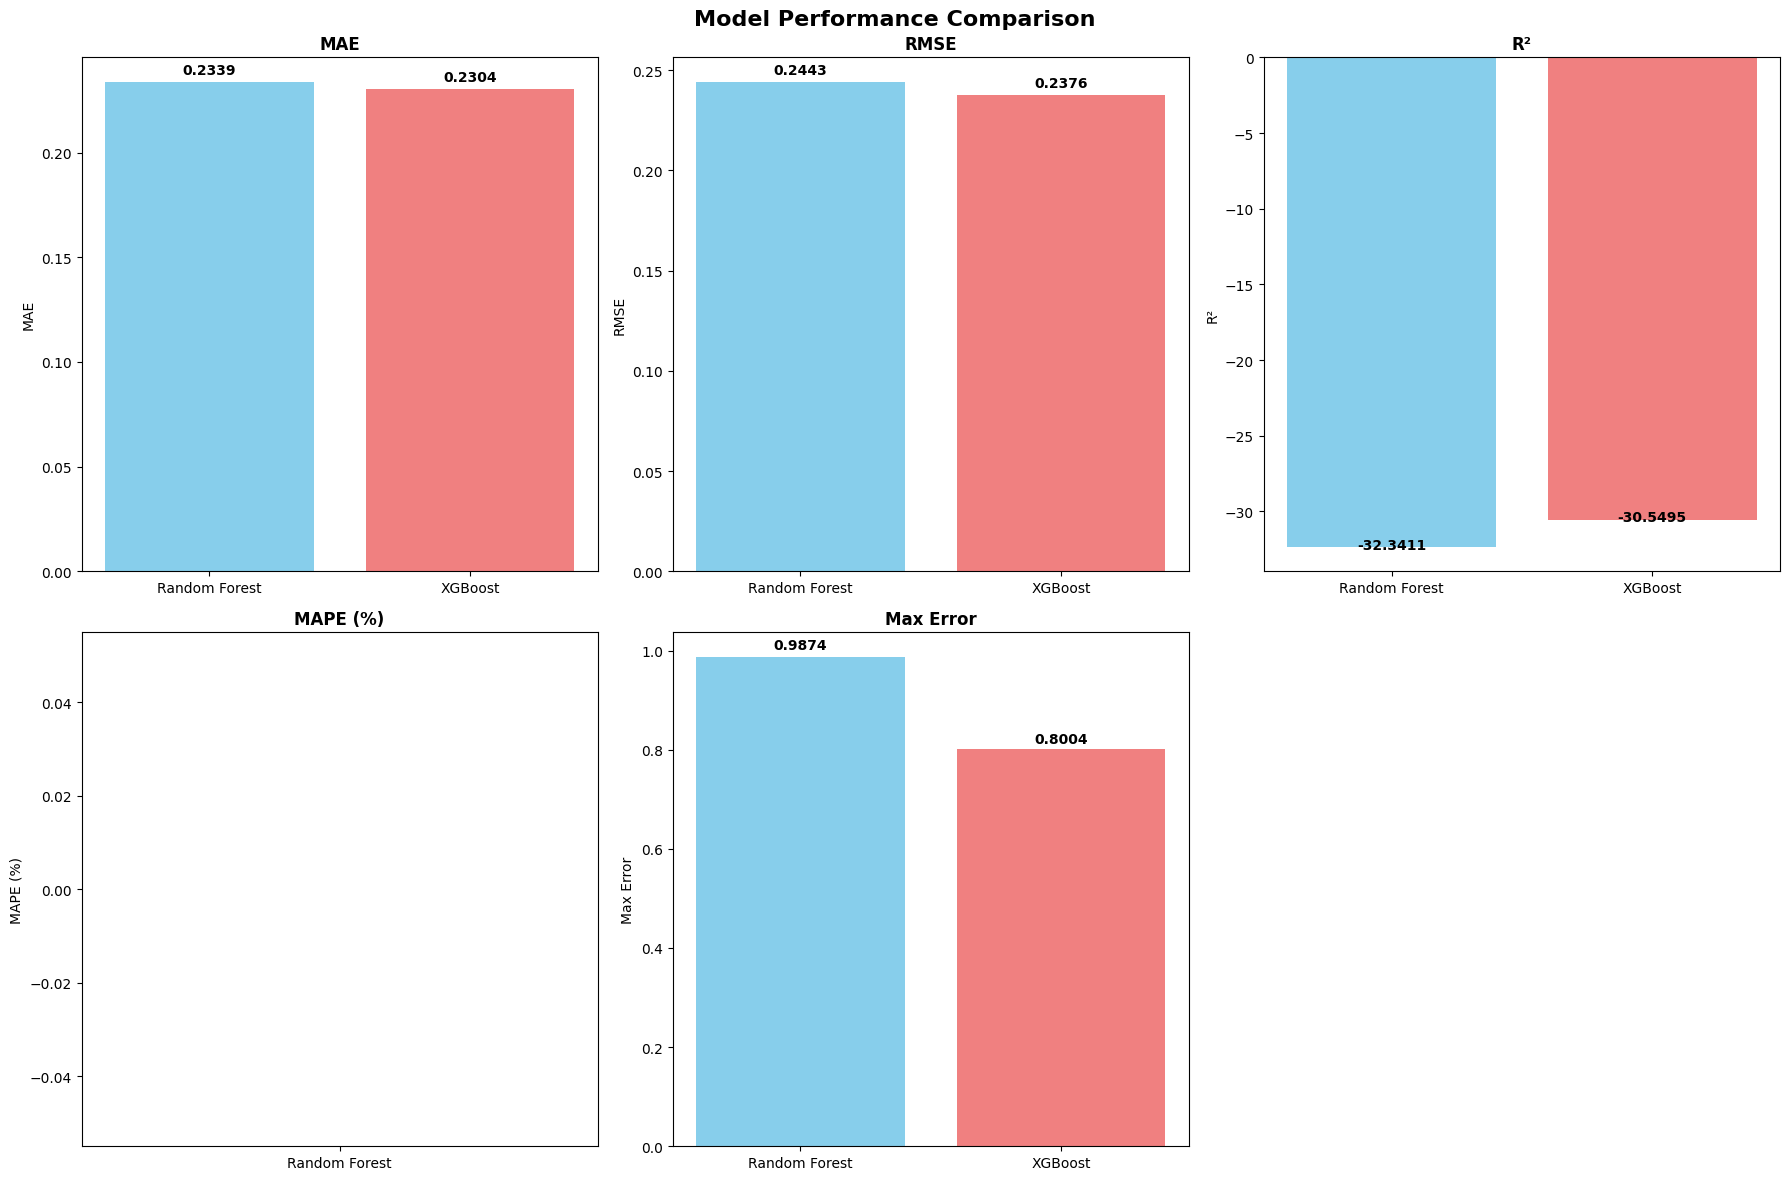

✅ Saved metrics_comparison.png


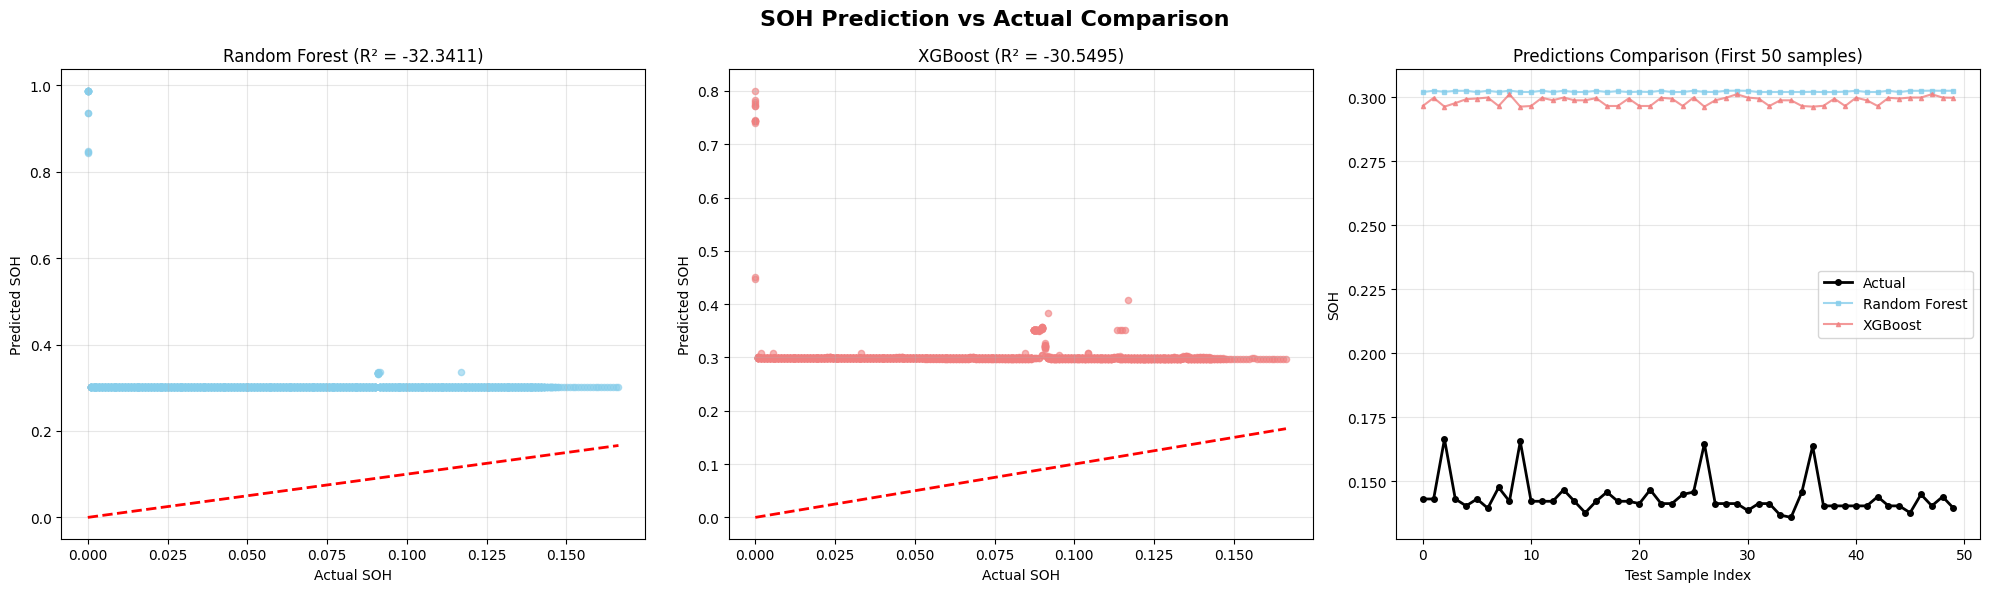

✅ Saved soh_pred_compare.png


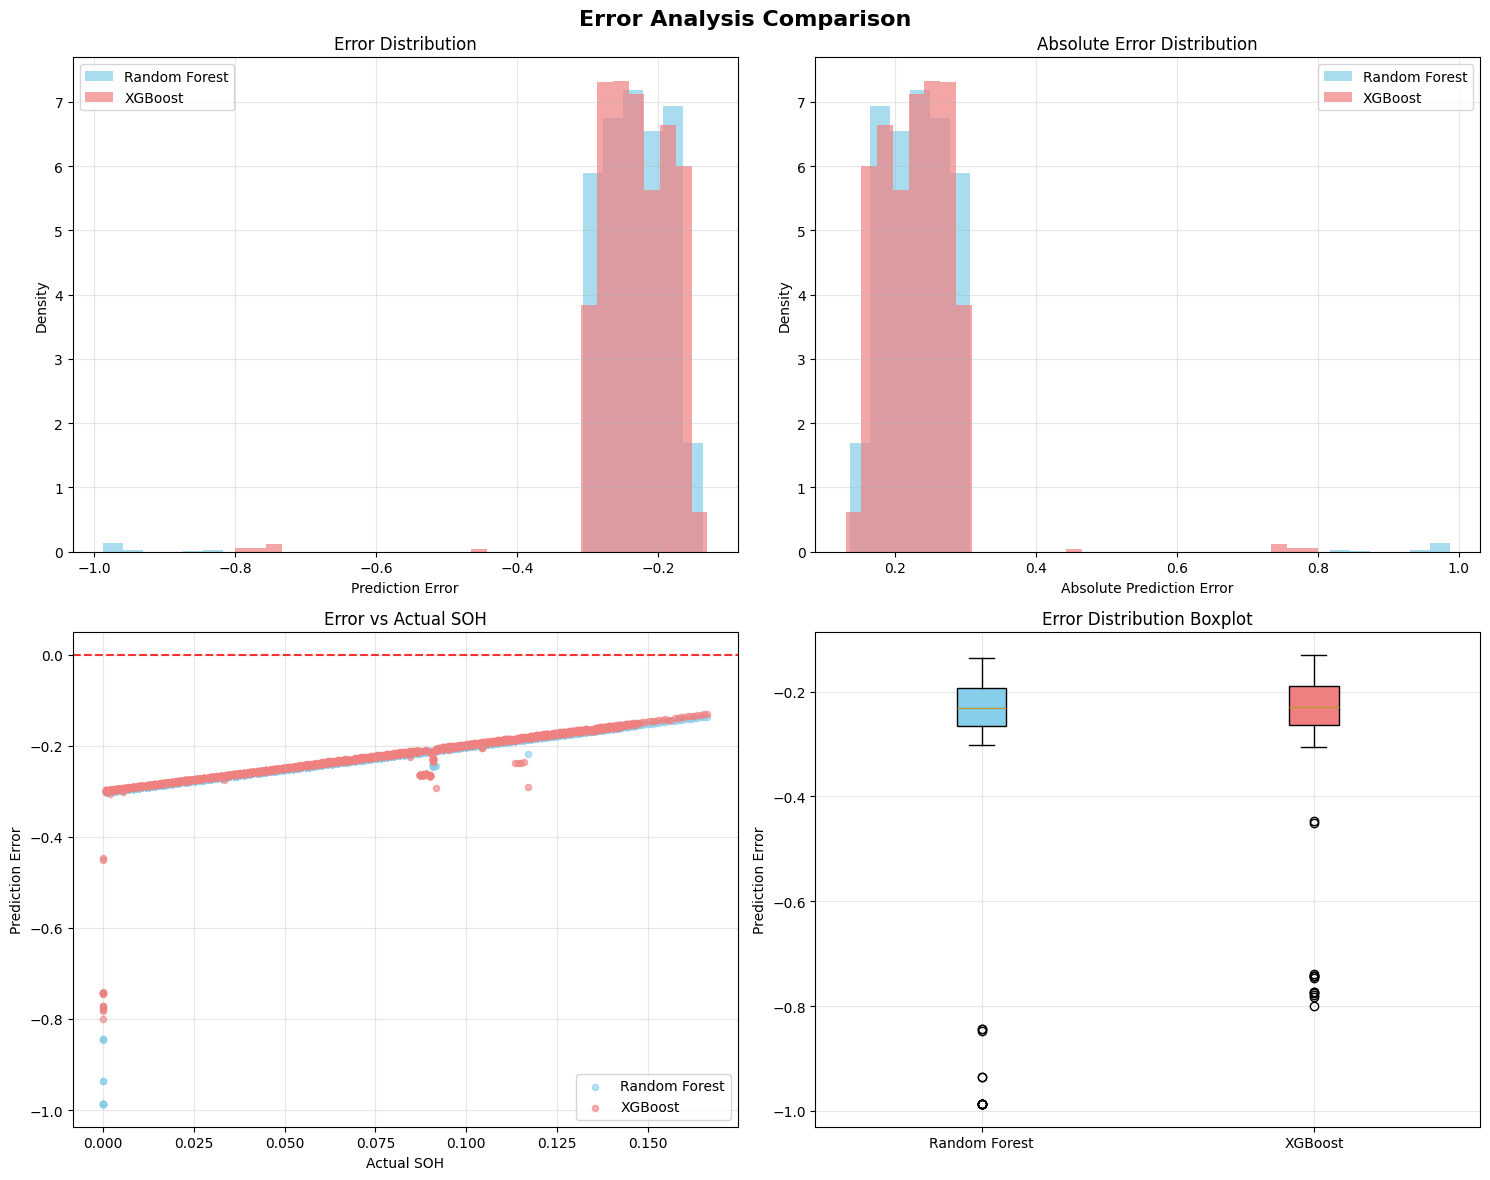

✅ Saved error_analysis.png

🔍 FEATURE IMPORTANCE COMPARISON
Top 10 Most Important Features (Average):
11. Rolling_SOH                    RF:0.6111 XGB:0.3650
 1. Discharge Time (s)             RF:0.3718 XGB:0.4685
 6. Time constant current (s)      RF:0.0000 XGB:0.0673
 4. Min. Voltage Charg. (V)        RF:0.0042 XGB:0.0265
10. Rolling_DischargeTime          RF:0.0121 XGB:0.0178
 9. Delta_SOH                      RF:0.0001 XGB:0.0164
 5. Time at 4.15V (s)              RF:0.0000 XGB:0.0149
 2. Decrement 3.6-3.4V (s)         RF:0.0000 XGB:0.0104
 3. Max. Voltage Dischar. (V)      RF:0.0000 XGB:0.0073
 8. Voltage_Range                  RF:0.0008 XGB:0.0047


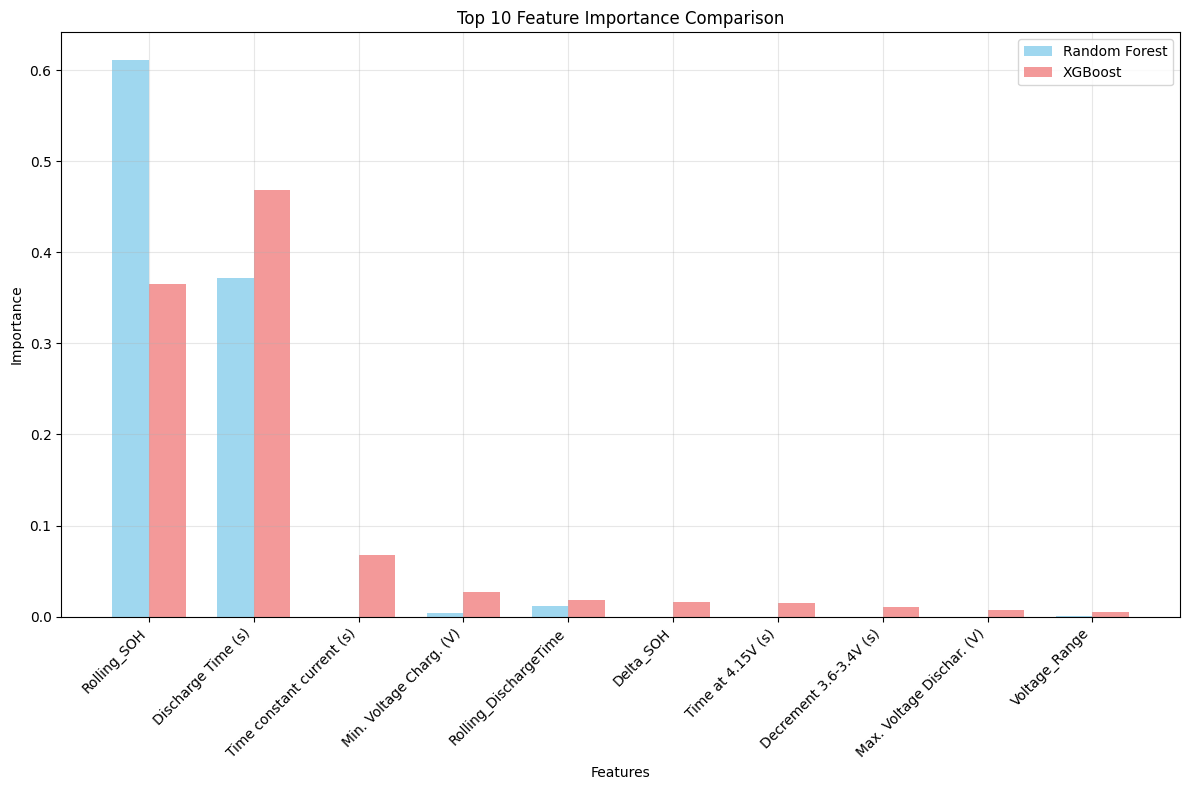

✅ Saved feature_importance.png
✅ Saved feature_importance_comparison.csv

🏆 FINAL MODEL COMPARISON SUMMARY
📊 Performance Comparison:
   Random Forest - RMSE: 0.2443, R²: -32.3411
   XGBoost       - RMSE: 0.2376, R²: -30.5495

🚀 XGBoost Improvements:
   RMSE Improvement: +2.72%
   R² Improvement:   -5.54%

🥇 WINNER: XGBoost (Lower RMSE)

✅ All visualizations saved to: ../models/
   📊 metrics_comparison.png
   📈 soh_pred_compare.png
   📉 error_analysis.png
   🔍 feature_importance.png

✅ All data files saved:
   📄 model_comparison.csv
   📄 feature_importance_comparison.csv

🎉 PHASE 3 COMPLETE - MODEL DEVELOPMENT & COMPARISON FINISHED!


In [2]:
# ================================
# MODEL COMPARISON AND ANALYSIS
# ================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

print("📊 COMPREHENSIVE MODEL COMPARISON")
print("=" * 60)

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

# ================================
# LOAD TEST DATA AND PREDICTIONS
# ================================

print("📂 Loading test data and model predictions...")

splits_dir = '../DATA/splits'
models_dir = '../models'

# Load test data
y_test = pd.read_csv(f'{splits_dir}/y_test.csv').iloc[:, 0]

# Load Random Forest predictions (from baseline model)
try:
    rf_model = joblib.load(f'{models_dir}/baseline_rf_model.pkl')
    rf_scaler = joblib.load(f'{models_dir}/feature_scaler.pkl')
    
    X_test = pd.read_csv(f'{splits_dir}/X_test.csv')
    X_test_scaled = rf_scaler.transform(X_test)
    rf_predictions = rf_model.predict(X_test_scaled)
    
    print("✅ Random Forest model loaded and predictions generated")
except Exception as e:
    print(f"❌ Error loading RF model: {e}")
    rf_predictions = None

# Load XGBoost predictions - CORRECTED FILE PATHS
try:
    # Try the correct file name and column from XGBoost notebook
    xgb_test_df = pd.read_csv(f'{models_dir}/xgb_test_predictions.csv')
    xgb_predictions = xgb_test_df['predicted'].values  # Column is 'predicted', not 'y_test_pred'
    
    print("✅ XGBoost predictions loaded")
except FileNotFoundError:
    try:
        # Fallback: try to load from all predictions file
        xgb_all_df = pd.read_csv(f'{models_dir}/xgb_all_predictions.csv')
        xgb_test_subset = xgb_all_df[xgb_all_df['dataset'] == 'test']
        xgb_predictions = xgb_test_subset['predicted'].values
        print("✅ XGBoost predictions loaded from combined file")
    except Exception as e:
        print(f"❌ Error loading XGBoost predictions: {e}")
        xgb_predictions = None
except Exception as e:
    print(f"❌ Error loading XGBoost predictions: {e}")
    xgb_predictions = None

# ================================
# CALCULATE COMPREHENSIVE METRICS
# ================================

def calculate_metrics(y_true, y_pred, model_name):
    """Calculate comprehensive metrics for a model"""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    # Additional metrics
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100  # Mean Absolute Percentage Error
    max_error = np.max(np.abs(y_true - y_pred))
    
    return {
        'Model': model_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R²': r2,
        'MAPE (%)': mape,
        'Max Error': max_error
    }

print("\n📊 CALCULATING COMPREHENSIVE METRICS")
print("=" * 50)

# Calculate metrics for both models
metrics_list = []

if rf_predictions is not None:
    rf_metrics = calculate_metrics(y_test, rf_predictions, 'Random Forest')
    metrics_list.append(rf_metrics)
    print("✅ Random Forest metrics calculated")

if xgb_predictions is not None:
    xgb_metrics = calculate_metrics(y_test, xgb_predictions, 'XGBoost')
    metrics_list.append(xgb_metrics)
    print("✅ XGBoost metrics calculated")

# Create comparison DataFrame
if metrics_list:
    comparison_df = pd.DataFrame(metrics_list)
    
    print("\n🏆 MODEL COMPARISON RESULTS")
    print("=" * 60)
    print(comparison_df.round(4).to_string(index=False))
    
    # Save comparison results
    comparison_df.to_csv(f'{models_dir}/model_comparison.csv', index=False)
    print(f"\n✅ Saved model_comparison.csv")

# ================================
# VISUALIZATION 1: METRICS COMPARISON
# ================================

if len(metrics_list) >= 2:
    print("\n📊 Generating comparison visualizations...")
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')
    
    metrics_to_plot = ['MAE', 'RMSE', 'R²', 'MAPE (%)', 'Max Error']
    colors = ['skyblue', 'lightcoral']
    
    for i, metric in enumerate(metrics_to_plot):
        row = i // 3
        col = i % 3
        
        values = [comparison_df[comparison_df['Model'] == model][metric].iloc[0] 
                 for model in comparison_df['Model']]
        models = comparison_df['Model'].tolist()
        
        bars = axes[row, col].bar(models, values, color=colors[:len(models)])
        axes[row, col].set_title(f'{metric}', fontweight='bold')
        axes[row, col].set_ylabel(metric)
        
        # Add value labels on bars
        for bar, value in zip(bars, values):
            height = bar.get_height()
            axes[row, col].text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                               f'{value:.4f}', ha='center', va='bottom', fontweight='bold')
    
    # Remove empty subplot
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig(f'{models_dir}/metrics_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Saved metrics_comparison.png")

# ================================
# VISUALIZATION 2: PREDICTION VS ACTUAL COMPARISON
# ================================

if rf_predictions is not None and xgb_predictions is not None:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle('SOH Prediction vs Actual Comparison', fontsize=16, fontweight='bold')
    
    # Random Forest
    axes[0].scatter(y_test, rf_predictions, alpha=0.6, color='skyblue', s=20)
    axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[0].set_xlabel('Actual SOH')
    axes[0].set_ylabel('Predicted SOH')
    axes[0].set_title(f'Random Forest (R² = {rf_metrics["R²"]:.4f})')
    axes[0].grid(True, alpha=0.3)
    
    # XGBoost
    axes[1].scatter(y_test, xgb_predictions, alpha=0.6, color='lightcoral', s=20)
    axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[1].set_xlabel('Actual SOH')
    axes[1].set_ylabel('Predicted SOH')
    axes[1].set_title(f'XGBoost (R² = {xgb_metrics["R²"]:.4f})')
    axes[1].grid(True, alpha=0.3)
    
    # Side by side comparison
    n_samples = min(50, len(y_test))  # Show first 50 samples for clarity
    x_pos = np.arange(n_samples)
    
    axes[2].plot(x_pos, y_test.iloc[:n_samples], 'ko-', label='Actual', markersize=4, linewidth=2)
    axes[2].plot(x_pos, rf_predictions[:n_samples], 's-', label='Random Forest', 
                markersize=3, alpha=0.8, color='skyblue')
    axes[2].plot(x_pos, xgb_predictions[:n_samples], '^-', label='XGBoost', 
                markersize=3, alpha=0.8, color='lightcoral')
    axes[2].set_xlabel('Test Sample Index')
    axes[2].set_ylabel('SOH')
    axes[2].set_title('Predictions Comparison (First 50 samples)')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{models_dir}/soh_pred_compare.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Saved soh_pred_compare.png")

# ================================
# VISUALIZATION 3: ERROR ANALYSIS
# ================================

if rf_predictions is not None and xgb_predictions is not None:
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Error Analysis Comparison', fontsize=16, fontweight='bold')
    
    # Calculate errors
    rf_errors = y_test - rf_predictions
    xgb_errors = y_test - xgb_predictions
    
    # Error histograms
    axes[0, 0].hist(rf_errors, bins=30, alpha=0.7, color='skyblue', label='Random Forest', density=True)
    axes[0, 0].hist(xgb_errors, bins=30, alpha=0.7, color='lightcoral', label='XGBoost', density=True)
    axes[0, 0].set_xlabel('Prediction Error')
    axes[0, 0].set_ylabel('Density')
    axes[0, 0].set_title('Error Distribution')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Absolute errors
    axes[0, 1].hist(np.abs(rf_errors), bins=30, alpha=0.7, color='skyblue', label='Random Forest', density=True)
    axes[0, 1].hist(np.abs(xgb_errors), bins=30, alpha=0.7, color='lightcoral', label='XGBoost', density=True)
    axes[0, 1].set_xlabel('Absolute Prediction Error')
    axes[0, 1].set_ylabel('Density')
    axes[0, 1].set_title('Absolute Error Distribution')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Error vs Actual SOH
    axes[1, 0].scatter(y_test, rf_errors, alpha=0.6, color='skyblue', s=20, label='Random Forest')
    axes[1, 0].scatter(y_test, xgb_errors, alpha=0.6, color='lightcoral', s=20, label='XGBoost')
    axes[1, 0].axhline(y=0, color='red', linestyle='--', alpha=0.8)
    axes[1, 0].set_xlabel('Actual SOH')
    axes[1, 0].set_ylabel('Prediction Error')
    axes[1, 0].set_title('Error vs Actual SOH')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Box plot comparison
    error_data = [rf_errors, xgb_errors]
    box_plot = axes[1, 1].boxplot(error_data, labels=['Random Forest', 'XGBoost'], patch_artist=True)
    colors = ['skyblue', 'lightcoral']
    for patch, color in zip(box_plot['boxes'], colors):
        patch.set_facecolor(color)
    axes[1, 1].set_ylabel('Prediction Error')
    axes[1, 1].set_title('Error Distribution Boxplot')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{models_dir}/error_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Saved error_analysis.png")

# ================================
# FEATURE IMPORTANCE COMPARISON
# ================================

print("\n🔍 FEATURE IMPORTANCE COMPARISON")
print("=" * 50)

try:
    # Load Random Forest feature importance
    rf_importance = pd.DataFrame({
        'feature': X_test.columns,
        'rf_importance': rf_model.feature_importances_
    })
    
    # Load XGBoost feature importance
    xgb_importance = pd.read_csv(f'{models_dir}/xgb_feature_importance.csv')
    
    # Merge importance data
    importance_comparison = rf_importance.merge(
        xgb_importance, on='feature', suffixes=('', '_xgb')
    ).rename(columns={'importance': 'xgb_importance'})
    
    # Sort by average importance
    importance_comparison['avg_importance'] = (
        importance_comparison['rf_importance'] + importance_comparison['xgb_importance']
    ) / 2
    importance_comparison = importance_comparison.sort_values('avg_importance', ascending=False)
    
    print("Top 10 Most Important Features (Average):")
    for i, row in importance_comparison.head(10).iterrows():
        print(f"{i+1:2d}. {row['feature']:30s} RF:{row['rf_importance']:.4f} XGB:{row['xgb_importance']:.4f}")
    
    # Plot feature importance comparison
    fig, ax = plt.subplots(figsize=(12, 8))
    top_features = importance_comparison.head(10)
    
    x = np.arange(len(top_features))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, top_features['rf_importance'], width, 
                   label='Random Forest', color='skyblue', alpha=0.8)
    bars2 = ax.bar(x + width/2, top_features['xgb_importance'], width,
                   label='XGBoost', color='lightcoral', alpha=0.8)
    
    ax.set_xlabel('Features')
    ax.set_ylabel('Importance')
    ax.set_title('Top 10 Feature Importance Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(top_features['feature'], rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{models_dir}/feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Saved feature_importance.png")
    
    # Save combined importance
    importance_comparison.to_csv(f'{models_dir}/feature_importance_comparison.csv', index=False)
    print("✅ Saved feature_importance_comparison.csv")
    
except Exception as e:
    print(f"⚠️ Could not compare feature importance: {e}")

# ================================
# FINAL SUMMARY TABLE
# ================================

print("\n" + "="*80)
print("🏆 FINAL MODEL COMPARISON SUMMARY")
print("="*80)

if len(metrics_list) >= 2:
    # Create a detailed summary
    summary_table = comparison_df.copy()
    
    # Add improvement metrics
    if 'Random Forest' in summary_table['Model'].values and 'XGBoost' in summary_table['Model'].values:
        rf_row = summary_table[summary_table['Model'] == 'Random Forest'].iloc[0]
        xgb_row = summary_table[summary_table['Model'] == 'XGBoost'].iloc[0]
        
        print(f"📊 Performance Comparison:")
        print(f"   Random Forest - RMSE: {rf_row['RMSE']:.4f}, R²: {rf_row['R²']:.4f}")
        print(f"   XGBoost       - RMSE: {xgb_row['RMSE']:.4f}, R²: {xgb_row['R²']:.4f}")
        
        rmse_improvement = ((rf_row['RMSE'] - xgb_row['RMSE']) / rf_row['RMSE']) * 100
        r2_improvement = ((xgb_row['R²'] - rf_row['R²']) / rf_row['R²']) * 100
        
        print(f"\n🚀 XGBoost Improvements:")
        print(f"   RMSE Improvement: {rmse_improvement:+.2f}%")
        print(f"   R² Improvement:   {r2_improvement:+.2f}%")
        
        # Determine best model
        if xgb_row['RMSE'] < rf_row['RMSE']:
            print(f"\n🥇 WINNER: XGBoost (Lower RMSE)")
        else:
            print(f"\n🥇 WINNER: Random Forest (Lower RMSE)")

print(f"\n✅ All visualizations saved to: {models_dir}/")
print(f"   📊 metrics_comparison.png")
print(f"   📈 soh_pred_compare.png") 
print(f"   📉 error_analysis.png")
print(f"   🔍 feature_importance.png")

print(f"\n✅ All data files saved:")
print(f"   📄 model_comparison.csv")
print(f"   📄 feature_importance_comparison.csv")

print("\n" + "="*80)
print("🎉 PHASE 3 COMPLETE - MODEL DEVELOPMENT & COMPARISON FINISHED!")
print("="*80)